In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from keras.layers import Dense, Input, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/abalone.csv")
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [22]:
df=df.drop("id", axis =1)
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [23]:
df.loc[df['Height'] == 0, 'Height'] = df['Height'].median() # 0값 대체
df = df[df['Height'] < 0.4] # 이상치 제거

In [24]:
#파생변수
df['Volume'] = df['Length'] * df['Diameter'] * df['Height'] # 부피 추정
df['Meat_Yield'] = df['Shucked_weight'] / df['Whole_weight'].replace(0, np.nan)
df['Meat_Yield'].fillna(df['Meat_Yield'].median(), inplace=True) # 무게 비율

/tmp/ipykernel_8299/2492937473.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Meat_Yield'].fillna(df['Meat_Yield'].median(), inplace=True) # 무게 비율


In [25]:
#원핫인코딩
df = pd.get_dummies(df, columns=['Sex'], prefix='Sex')

In [26]:
selected_features = [
    'Length', 'Diameter', 'Height',
    'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight',
    'Volume', 'Meat_Yield',
    'Sex_F', 'Sex_I', 'Sex_M'
]
X = df[selected_features].values
X

array([[0.455, 0.365, 0.095, ..., False, False, True],
       [0.35, 0.265, 0.09, ..., False, False, True],
       [0.53, 0.42, 0.135, ..., True, False, False],
       ...,
       [0.6, 0.475, 0.205, ..., False, False, True],
       [0.625, 0.485, 0.15, ..., True, False, False],
       [0.71, 0.555, 0.195, ..., False, False, True]], dtype=object)

In [27]:
y = df['Rings']
y

,Rings
0,15
1,7
2,9
3,10
4,7
...,...
4172,11
4173,10
4174,9
4175,10


In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)



In [29]:
#스케일링
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)

y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_s  = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

In [30]:
#Defining the model

from keras.models import Sequential
from keras.optimizers import SGD,Adam
from keras.layers import Dense, Input, Dropout

model = Sequential([
    Input(shape=(12,)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [31]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape,

((3340, 12), (3340,), (835, 12), (835,))

In [32]:
early_stop = EarlyStopping(monitor='val_loss', patience=15,
                            restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=7, min_lr=1e-6, verbose=1)

N_EPOCHS = 200
history = model.fit(X_train, y_train_s,
                    epochs=N_EPOCHS, batch_size=32,
                    validation_data=(X_test, y_test_s),
                    callbacks=[early_stop, reduce_lr])
y_pred = model.predict(X_test)
print(f"실제 학습 epoch: {len(history.history['loss'])}")

Epoch 1/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.1127 - mae: 0.7984 - val_loss: 0.7476 - val_mae: 0.6073 - learning_rate: 0.0010
Epoch 2/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6458 - mae: 0.6101 - val_loss: 0.6216 - val_mae: 0.5413 - learning_rate: 0.0010
Epoch 3/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5903 - mae: 0.5707 - val_loss: 0.5590 - val_mae: 0.4989 - learning_rate: 0.0010
Epoch 4/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5739 - mae: 0.5565 - val_loss: 0.5626 - val_mae: 0.4768 - learning_rate: 0.0010
Epoch 5/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5296 - mae: 0.5363 - val_loss: 0.5417 - val_mae: 0.4733 - learning_rate: 0.0010
Epoch 6/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5276 - mae: 0.5235 - val_loss: 0.4910 - val_mae: 0.4601 - learning_rate: 0.0010
Epoch 7/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5109 - mae: 0.5261 - val_loss: 0.4807 - val_mae: 0.4533 - learning_rate: 0.0010

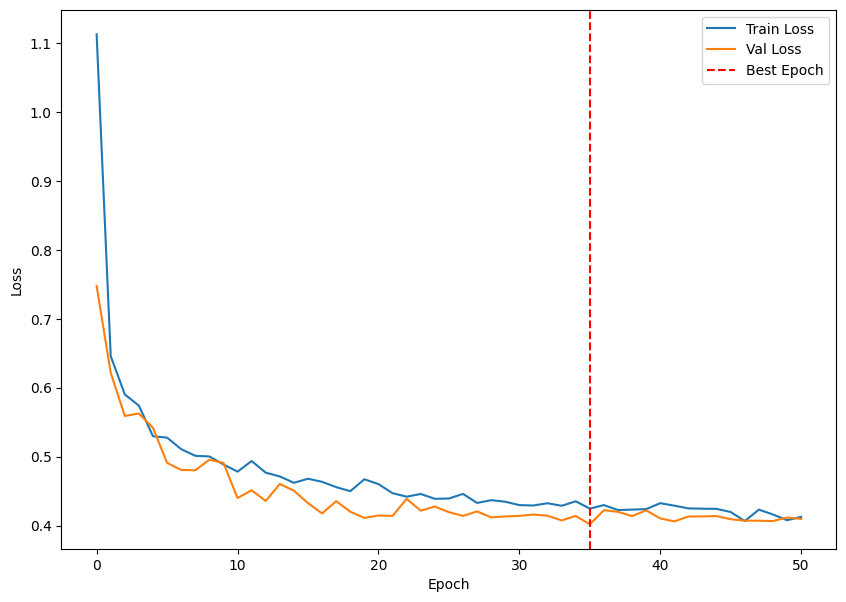

In [33]:
# loss 체크
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
epochs_ran = len(history.history['loss'])
plt.plot(range(epochs_ran), history.history['loss'], label='Train Loss')
plt.plot(range(epochs_ran), history.history['val_loss'], label='Val Loss')
plt.axvline(np.argmin(history.history['val_loss']), color='red',
            linestyle='--', label='Best Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [34]:
model.evaluate(X_test, y_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 105.2154 - mae: 9.8948 


[105.21543884277344, 9.894804000854492]

In [35]:
y_pred_s = y_pred.flatten()

In [36]:
y_pred_s    = y_pred.flatten()
y_pred_orig = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
y_test_orig = y_test.astype(float)  # 원본 정수값 그대로

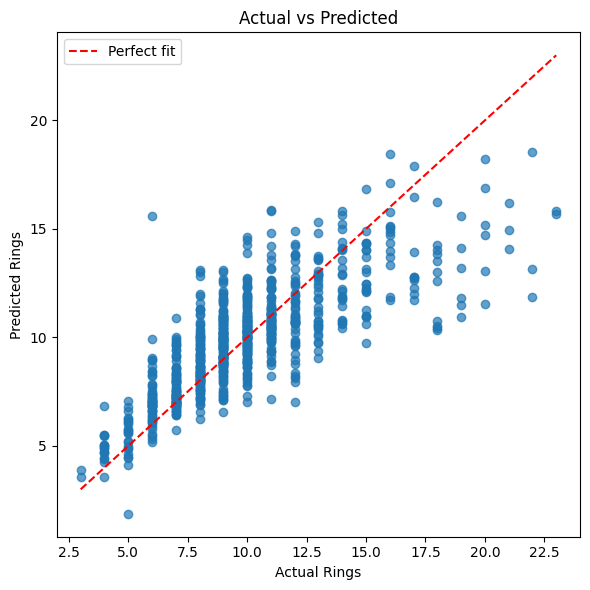

In [37]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.7)
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()],
         'r--', label='Perfect fit')
plt.xlabel('Actual Rings')
plt.ylabel('Predicted Rings')
plt.title('Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
#평가지표
y_pred_round = np.round(y_pred_orig).astype(int)

mae  = mean_absolute_error(y_test_orig, y_pred_orig)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
r2   = r2_score(y_test_orig, y_pred_orig)

mae_r  = mean_absolute_error(y_test_orig, y_pred_round)
rmse_r = np.sqrt(mean_squared_error(y_test_orig, y_pred_round))
r2_r   = r2_score(y_test_orig, y_pred_round)

print("=" * 45)
print(f"{'지표':<12} {'연속 예측':>12} {'반올림 예측':>12}")
print("=" * 45)
print(f"{'MAE':<12} {mae:>12.4f} {mae_r:>12.4f}")
print(f"{'RMSE':<12} {rmse:>12.4f} {rmse_r:>12.4f}")
print(f"{'R²':<12} {r2:>12.4f} {r2_r:>12.4f}")
print("=" * 45)

지표                  연속 예측       반올림 예측
MAE                1.4261       1.4120
RMSE               2.0380       2.0605
R²                 0.6101       0.6014
